# EE-411 Lottery Ticket Hypothesis - Experiment Template

**Author:** Jerry 
**Model:** ResNet 18
**Dataset:** [MNIST / CIFAR-10]  
**Date:** 2026.01.06

---

## Instructions

1. **Define your model** in the "Model Definition" section
2. **Train baseline model** to get initial performance
3. **Run pruning experiments** using the shared pruning algorithms
4. **Visualize and analyze** your results
5. **Save your results** to the `results/` folder

## Quick Links

- [Paper](https://arxiv.org/abs/1803.03635): "The Lottery Ticket Hypothesis"
- [Shared Code](../../shared/): Training utils and pruning algorithms
- [Results](../../results/): Save checkpoints and figures here

## 1. Setup and Imports

In [1]:
import sys
sys.path.append('../..')  # Add project root to path

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import shared utilities
from shared.training_utils import fit, predict
from shared.pruning import (
    iterative_pruning,
    one_shot_pruning,
    get_pruning_config,
    count_parameters,
    evaluate_model
)

# Fix random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading

### For CIFAR-10 (Conv-2, Conv-4, Conv-6, ResNet-18)

In [2]:
# CIFAR-10 Data Loading

# Define transforms
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Download and load datasets
train_dataset_full = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=True, 
    download=True, 
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root='../../data', 
    train=False, 
    download=True, 
    transform=transform_test
)

# Split train into train/val (45k train, 5k val)
train_size = 45000
val_size = 5000
train_dataset, val_dataset = random_split(
    train_dataset_full, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

# Create data loaders
batch_size = 60  # From paper

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=2
)

print(f"Train: {len(train_dataset)} samples")
print(f"Val:   {len(val_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Batches per epoch: {len(train_loader)}")

Train: 45000 samples
Val:   5000 samples
Test:  10000 samples
Batches per epoch: 750


### For MNIST (LeNet)

In [ ]:
# MNIST Data Loading (Uncomment if using LeNet)

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,))
# ])

# train_dataset_full = torchvision.datasets.MNIST(
#     root='../../data',
#     train=True,
#     download=True,
#     transform=transform
# )

# test_dataset = torchvision.datasets.MNIST(
#     root='../../data',
#     train=False,
#     download=True,
#     transform=transform
# )

# # Split train/val (55k train, 5k val)
# train_size = 55000
# val_size = 5000
# train_dataset, val_dataset = random_split(
#     train_dataset_full,
#     [train_size, val_size],
#     generator=torch.Generator().manual_seed(seed)
# )

# batch_size = 60

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# print(f"Train: {len(train_dataset)} samples")
# print(f"Val:   {len(val_dataset)} samples")
# print(f"Test:  {len(test_dataset)} samples")

## 3. Model Definition

**TODO: Define your model here**

In [3]:
# Example: Conv-2 for CIFAR-10
# Replace this with your own model!

class Conv2(nn.Module):
    """
    Conv-2 for CIFAR-10 (from paper Figure 2)
    
    Architecture:
    - Module 1: 64 conv 3x3 → 64 conv 3x3 → maxpool 2x2
    - FC: 256 → 256 → 10
    
    Total params: ~1.93M (38K conv + 1.89M fc)
    """
    def __init__(self):
        super(Conv2, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Fully connected layers
        # After one pool: 32x32 -> 16x16
        self.fc1 = nn.Linear(64 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 10)
        
        self.relu = nn.ReLU()
        
        # Initialize weights (Gaussian Glorot from paper)
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Conv module
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # FC layers
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x


# Create model instance
model = Conv2().to(device)

# Print model info
total_params = count_parameters(model)
print(f"Model: Conv2")
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

Model: Conv2
Total parameters: 4,301,642

Model architecture:
Conv2(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)


## 4. Baseline Training

Train the unpruned model to establish baseline performance.

In [4]:
# Training configuration (from paper)
# Adjust these based on your model!

learning_rate = 2e-4  # Conv-2 uses Adam with lr=2e-4
epochs = 27           # ~20K iterations / (45K samples / 60 batch) ≈ 27 epochs

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Training configuration:")
print(f"  Optimizer: Adam")
print(f"  Learning rate: {learning_rate}")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"\nStarting training...\n")

# Train using shared training_utils
losses = fit(
    model=model,
    train_dataloader=train_loader,
    optimizer=optimizer,
    epochs=epochs,
    device=device
)

# Evaluate on test set
test_loss, test_accuracy = predict(model, test_loader, device)

print(f"\n{'='*60}")
print(f"Baseline Results")
print(f"{'='*60}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Training configuration:
  Optimizer: Adam
  Learning rate: 0.0002
  Epochs: 27
  Batch size: 60

Starting training...

Epoch 0: Loss=1.374780690908432
Epoch 1: Loss=0.9579414552052816
Epoch 2: Loss=0.7734357605775197
Epoch 3: Loss=0.6211400899092356
Epoch 4: Loss=0.4771455571651459
Epoch 5: Loss=0.33604054206609724
Epoch 6: Loss=0.21497602649529776
Epoch 7: Loss=0.1224344511901339
Epoch 8: Loss=0.0753521272316575
Epoch 9: Loss=0.05969544913868109
Epoch 10: Loss=0.045425244607341785
Epoch 11: Loss=0.04390408218093216
Epoch 12: Loss=0.035975614691153165
Epoch 13: Loss=0.03921730181481689
Epoch 14: Loss=0.028316924289179344
Epoch 15: Loss=0.026982663691354294
Epoch 16: Loss=0.030389537609259908
Epoch 17: Loss=0.02329981440596748
Epoch 18: Loss=0.023061797312926503
Epoch 19: Loss=0.02567178031569347
Epoch 20: Loss=0.019797311130096206
Epoch 21: Loss=0.021065735928326224
Epoch 22: Loss=0.02020282349459982
Epoch 23: Loss=0.016510294231392133
Epoch 24: Loss=0.018858273699860244
Epoch 25: Loss

### Visualize Training

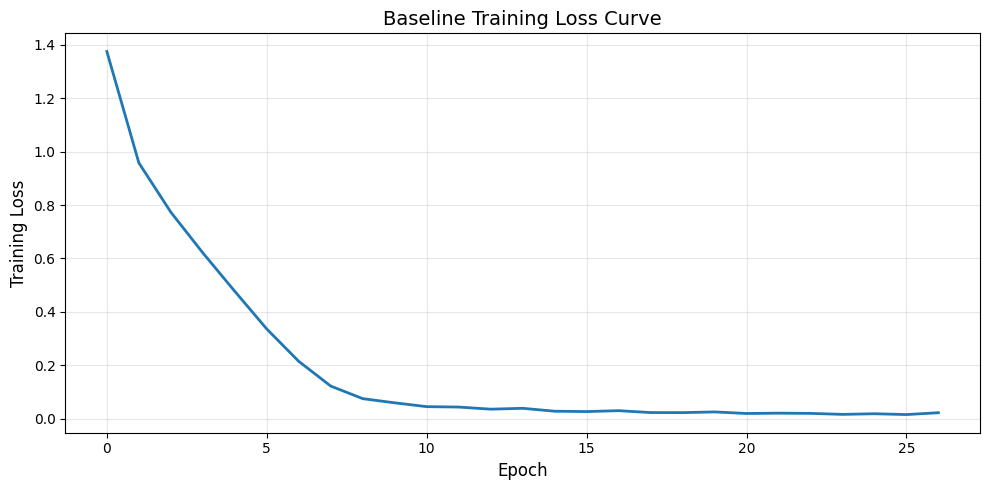

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Baseline Training Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../results/figures/baseline_training_loss.png', dpi=150)
plt.show()

### Save Baseline Model

In [6]:
# Save baseline model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'test_accuracy': test_accuracy,
    'test_loss': test_loss,
    'epochs': epochs,
}, '../../results/checkpoints/baseline_model.pth')

print("Baseline model saved to results/checkpoints/baseline_model.pth")

Baseline model saved to results/checkpoints/baseline_model.pth


## 5. Iterative Pruning Experiments

Run the main pruning experiment from the paper.

In [7]:
# Get pruning configuration for your model
# Options: 'lenet', 'conv2', 'conv4', 'conv6', 'resnet18'

pruning_config = get_pruning_config('conv2')  # Change this for your model

print("Pruning Configuration:")
for key, value in pruning_config.items():
    print(f"  {key}: {value}")

# Or customize your own config
# pruning_config = {
#     'prune_rate_conv': 0.1,
#     'prune_rate_fc': 0.2,
#     'pruning_strategy': 'layerwise'
# }

Pruning Configuration:
  prune_rate_conv: 0.1
  prune_rate_fc: 0.2
  pruning_strategy: layerwise
  description: Conv-2 for CIFAR-10


In [8]:
# Create fresh model for pruning
model_pruning = Conv2().to(device)  # Replace with your model

# Run iterative pruning
results = iterative_pruning(
    model=model_pruning,
    train_loader=train_loader,
    test_loader=test_loader,
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={'lr': learning_rate},
    device=device,
    config=pruning_config,
    n_rounds=10,           # Start with 10 rounds for testing
    epochs_per_round=20,   # Epochs per pruning round
    verbose=True
)

print("\nPruning experiment complete!")

Starting Iterative Pruning
Initial parameters: 4,301,642
Pruning strategy: layerwise
Conv prune rate: 10.0%
FC prune rate: 20.0%

Round 1/10


Epoch 1/20: 100%|██████████| 750/750 [00:04<00:00, 161.42it/s]


Epoch 1/20, Loss: 1.3896


Epoch 2/20: 100%|██████████| 750/750 [00:04<00:00, 172.33it/s]


Epoch 2/20, Loss: 0.9855


...

Epoch 19/20: 100%|██████████| 750/750 [00:04<00:00, 170.92it/s]


Epoch 19/20, Loss: 0.0257


Epoch 20/20: 100%|██████████| 750/750 [00:04<00:00, 163.10it/s]

Epoch 20/20, Loss: 0.0248



Round 10 Results:
  Test Accuracy: 68.82%
  Remaining Parameters: 3,445,301.0 (80.09%)

Iterative Pruning Complete!

Pruning experiment complete!


## 6. Analyze Results

Visualize and analyze the pruning results.

In [9]:
# Extract data for plotting
rounds = [r['round'] for r in results]
test_accuracies = [r['test_accuracy'] for r in results]
remaining_params_pct = [r['remaining_params_pct'] for r in results]
remaining_params = [r['remaining_params'] for r in results]

# Print summary
print("\n" + "="*70)
print("Pruning Results Summary")
print("="*70)
print(f"{'Round':<8} {'Params %':<12} {'Params':<15} {'Test Acc %':<12}")
print("-"*70)
for r in results:
    print(f"{r['round']:<8} {r['remaining_params_pct']:<12.2f} "
          f"{r['remaining_params']:<15,} {r['test_accuracy']:<12.2f}")
print("="*70)


Pruning Results Summary
Round    Params %     Params          Test Acc %  
----------------------------------------------------------------------
1        80.09        3,445,302.0     68.50       
2        80.09        3,445,301.0     67.78       
3        80.09        3,445,302.0     68.35       
4        80.09        3,445,301.0     68.69       
5        80.09        3,445,301.0     68.58       
6        80.09        3,445,301.0     68.19       
7        80.09        3,445,302.0     68.98       
8        80.09        3,445,301.0     68.75       
9        80.09        3,445,301.0     68.90       
10       80.09        3,445,301.0     68.82       


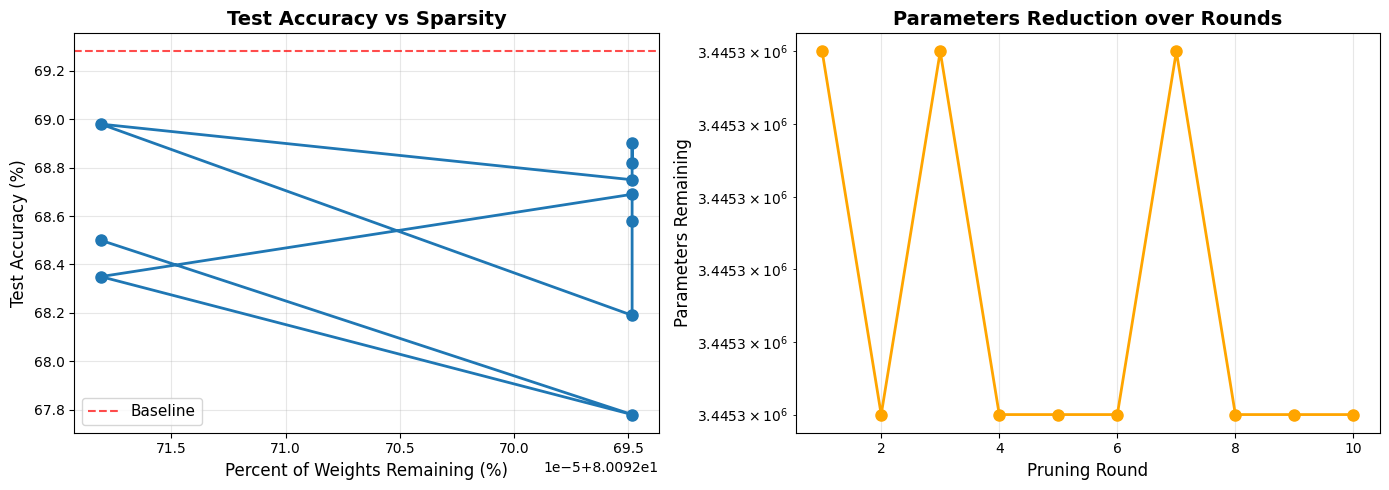


Figure saved to results/figures/pruning_results.png


In [11]:
# Visualize results (similar to paper Figure 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Test Accuracy vs Sparsity
ax1.plot(remaining_params_pct, test_accuracies, 'o-', linewidth=2, markersize=8)
# ax1.axhline(y=test_accuracy, color='r', linestyle='--', label='Baseline', alpha=0.7) # If you are using CPU, use this line
ax1.axhline(y=test_accuracy.item(), color='r', linestyle='--', label='Baseline', alpha=0.7) # If you are using GPU (cuda), use this line
ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Test Accuracy vs Sparsity', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.invert_xaxis()  # More sparse on the right

# Right plot: Parameters Remaining
ax2.plot(rounds, remaining_params, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Pruning Round', fontsize=12)
ax2.set_ylabel('Parameters Remaining', fontsize=12)
ax2.set_title('Parameters Reduction over Rounds', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('../../results/figures/pruning_results.png', dpi=150)
plt.show()

print("\nFigure saved to results/figures/pruning_results.png")

## 7. Identify Winning Tickets

Find which pruned networks are "winning tickets" (match or exceed baseline accuracy).

In [12]:
# Identify winning tickets
baseline_accuracy = test_accuracy
winning_tickets = []

for r in results:
    # Winning ticket criteria: accuracy >= 98% of baseline
    if r['test_accuracy'] >= baseline_accuracy * 0.98:
        winning_tickets.append(r)

print(f"\n{'='*70}")
print(f"Found {len(winning_tickets)} Winning Tickets!")
print(f"{'='*70}")
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print(f"\nWinning Tickets (accuracy >= {baseline_accuracy * 0.98:.2f}%):")
print(f"{'Round':<8} {'Sparsity %':<12} {'Params':<15} {'Accuracy %':<12}")
print("-"*70)

for ticket in winning_tickets:
    sparsity = 100 - ticket['remaining_params_pct']
    print(f"{ticket['round']:<8} {sparsity:<12.1f} "
          f"{ticket['remaining_params']:<15,} {ticket['test_accuracy']:<12.2f}")

if winning_tickets:
    best_ticket = min(winning_tickets, key=lambda x: x['remaining_params'])
    print(f"\nBest Winning Ticket:")
    print(f"  Round: {best_ticket['round']}")
    print(f"  Sparsity: {100 - best_ticket['remaining_params_pct']:.1f}%")
    print(f"  Parameters: {best_ticket['remaining_params']:,}")
    print(f"  Accuracy: {best_ticket['test_accuracy']:.2f}%")


Found 9 Winning Tickets!
Baseline Accuracy: 69.28%

Winning Tickets (accuracy >= 67.89%):
Round    Sparsity %   Params          Accuracy %  
----------------------------------------------------------------------
1        19.9         3,445,302.0     68.50       
3        19.9         3,445,302.0     68.35       
4        19.9         3,445,301.0     68.69       
5        19.9         3,445,301.0     68.58       
6        19.9         3,445,301.0     68.19       
7        19.9         3,445,302.0     68.98       
8        19.9         3,445,301.0     68.75       
9        19.9         3,445,301.0     68.90       
10       19.9         3,445,301.0     68.82       

Best Winning Ticket:
  Round: 4
  Sparsity: 19.9%
  Parameters: 3,445,301.0
  Accuracy: 68.69%


## 8. Save Results

In [13]:
import json

# Save results to JSON
results_dict = {
    'model': 'Conv2',  # Change this
    'dataset': 'CIFAR-10',
    'baseline_accuracy': float(baseline_accuracy),
    'pruning_config': pruning_config,
    'pruning_results': results,
    'winning_tickets': winning_tickets
}

with open('../../results/pruning_results.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print("Results saved to results/pruning_results.json")

Results saved to results/pruning_results.json


## 9. Next Steps

### Experiment Ideas:

1. **Compare pruning strategies**
   - Try different `prune_rate_conv` and `prune_rate_fc`
   - Compare `layerwise` vs `global` pruning

2. **Random reinitialization baseline**
   - Use `random_reinit_pruning()` to show winning tickets need original initialization

3. **One-shot pruning**
   - Compare `one_shot_pruning()` vs iterative pruning

4. **Visualize weight distributions**
   - Plot weight magnitude histograms before/after pruning

5. **Learning rate experiments**
   - Test different learning rates (paper shows this matters!)

### For Team Meeting (Jan 10):

- Share your baseline accuracy
- Show your pruning curves
- Discuss any challenges or interesting findings
- Compare results across different models

## Notes and Observations

**TODO: Add your observations here**

- What worked well?
- What surprised you?
- Any implementation challenges?
- Ideas for the final report?